## 1. Environment Setup & Data Loading

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

# Add project root to sys.path to import modular pipeline
sys.path.append(os.path.abspath("../"))
from src.feature_engineering import load_data, run_feature_engineering_pipeline, prepare_datasets

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, 
                             median_absolute_error, mean_absolute_percentage_error)

sns.set_theme(style="whitegrid")
%matplotlib inline

In [ ]:
import os
import pandas as pd
from src.feature_engineering import load_data, run_feature_engineering_pipeline, prepare_datasets

# Define paths
data_path = "../data/laptopData.csv"

# Load raw data
df_raw = load_data(data_path)

# Run individual feature engineering (Spec-based features like PPI, CPU Tier, etc.)
# This does not include brand ratings yet to avoid any leakage before splitting
df_intermediate = run_feature_engineering_pipeline(df_raw)

# Split and Scale with no leakage
# Brand Ratings are now calculated internally in prepare_datasets 
# using only the training set's target distribution
X_train, X_test, y_train, y_test, scaler = prepare_datasets(df_intermediate)

print(f"Data loaded from: {data_path}")
print(f"Total features after encoding: {X_train.shape[1]}")
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")


Data loaded from: ../data/laptopData.csv
Total features after encoding: 58
Training set: (1018, 58)
Testing set: (254, 58)


## 2. Model Training & Comparison

In [3]:
def calculate_price_metrics(y_true_log, y_pred_log):
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2 Score": r2_score(y_true_log, y_pred_log),
        "MAE (Price)": mean_absolute_error(y_true, y_pred),
        "MSE (Price)": mse,
        "RMSE (Price)": np.sqrt(mse),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred)
    }

def evaluate_models(models, X_train, X_test, y_train, y_test):
    results = []
    for name, model in models.items():
        start_time = time()
        model.fit(X_train, y_train)
        train_time = time() - start_time
        y_pred = model.predict(X_test)
        
        # Metrics on Log Price
        mae_log = mean_absolute_error(y_test, y_pred)
        
        metrics = calculate_price_metrics(y_test, y_pred)
        res = {"Model": name, "Time (s)": train_time, "MAE (Log)": mae_log}
        res.update(metrics)
        results.append(res)
        
    return pd.DataFrame(results)
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel='rbf'),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "CatBoost": CatBoostRegressor(n_estimators=100, verbose=0, random_state=42),
    "Stacked Generalizer": StackingRegressor(
        estimators=[
            ('xgb', XGBRegressor(n_estimators=100, random_state=42)),
            ('cat', CatBoostRegressor(n_estimators=100, verbose=0, random_state=42)),
            ('et', ExtraTreesRegressor(n_estimators=100, random_state=42)),
            ('svr', SVR(kernel='rbf', C=10))
        ],
        final_estimator=RidgeCV(),
        cv=5,
        n_jobs=-1
    )
}

results_df = evaluate_models(models, X_train, X_test, y_train, y_test)
results_df = results_df.sort_values(by="R2 Score", ascending=False)
display(results_df[["Model", "R2 Score", "MAE (Price)", "MSE (Price)", "RMSE (Price)", "MAPE", "Time (s)"]])

,Model,R2 Score,MAE (Price),MSE (Price),RMSE (Price),MAPE,Time (s)
10,Stacked Generalizer,0.906770,8708.293651,2.445173e+08,15637.047411,0.138476,8.395629
9,CatBoost,0.894124,9440.818988,2.699499e+08,16430.153154,0.150911,0.206332
8,XGBoost,0.889221,9470.713213,2.938918e+08,17143.273803,0.147217,0.324513
4,Gradient Boosting,0.886403,9711.459399,2.806721e+08,16753.270852,0.159688,0.190296
3,Random Forest,0.882636,9412.213946,2.665821e+08,16327.341796,0.155398,0.685601
6,SVR,0.877195,10248.677171,3.795419e+08,19481.834352,0.164866,0.048545
5,Extra Trees,0.874202,9933.846959,3.052819e+08,17472.318738,0.162017,0.469929
2,Lasso,0.849986,11504.056623,2.850982e+08,16884.851795,0.193377,0.018062
7,KNN,0.845563,11626.934085,4.334679e+08,20819.891966,0.186166,0.001620
1,Ridge,0.844380,12674.636105,4.767431e+08,21834.448067,0.199922,0.011057


Baseline Rankings: 

It can be seen that stacked generalizer (combination of XGBoost Regressor, CatBoost Regressor, Extra Trees Regressor, and SVR), CatBoost Regressor, XGBoost Regressor, Gradient Boosting Regressor, and Random Forest Regressor performed the best in terms of highest R^2. The reasons these models excel on this dataset is their ability to handle high-dimensional and sparse data with complex interactions. The multiple one-hot encoding of brands, hardware types, etc. results in sparse data that tree models are best at. While Linear Regression and Ridge struggle because they assume each feature adds a fixed amount to the price independently, the tree-based ensembles capture complex "premise-based" interactions, such as the synergistic effect where a high-end GPU combined with high RAM creates a price spike that exceeds the sum of their individual parts. Linear models assume each feature adds a fixed amount to the price independently, which the EDA and correlation matrix revealed was not the case for this dataset. 

CatBoost is the best individual model as its algorithm is specifically optimized for categorical interactions, allowing it to understand this heavily categorical dataset. CatBoost has a unique implementation of Symmetrics Trees and Ordered Boosting. Unlike other gradient boosters, CatBoost's symmetric structure acts as a natural regularizer.  

XGBoost's superior performance (in terms of R^2) in this dataset is driven by its sparsity-aware split finding, which efficiently handles the high-dimensional data generated by one-hot-encoded brand and CPU features. Unlike Random Forest's simple averaging, XGBoost's sequential boosting approach iteratively corrects its own residuals, while its built-in L1/L2 regularization prevents it from overfitting to rare, high-end outliers.

In terms of MAE, Random Forest performed better than XGBoost and Gradient Boosting because its bagging method is highly robust to outliers. While it may not capture every nuance of as perfectly as XGBoost or Gradient Boost, it is very consistent across the "average" laptops, leading to a smaller average error.

The strategic composition of StackingRegressor: Random Forest and Gradient Boosting are omitted to maximize algorithmic diversity. Including both Random Forest and Extra Trees would be redundant, and Extra Trees introduces even more randomization, providing the meta-learner with a unique perspective on the data's outliers. Similarly, by favouring XGBoost over Gradient Boosting and adding geometrically distinct SVR, the stack ensures that the meta-learner receives a diverse set of "opinions" rather than a repetitive echo-chamber of similar tree-based predictions. StackingRegressor is the best performer because it takes multiple base regression models, then uses their output predictions as input features to train a final "meta" model to generate the final prediction. This reduces individual model errors and overcoming overfitting when used with cross-validation. Each model has its blindspots, StackingRegressor uses CV to generate out of fold predictions, which means RidgeCV meta-learner is actually training on how well those base models performed on data they haven't seen yet.

In [4]:
# Avg Error seemed way too high (~8.5K INR), so comparing to baseline model that predicts average
# price for every laptop
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mae = mean_absolute_error(np.exp(y_test), np.exp(baseline_pred))

print(baseline_mae)


26392.552266642604


It can be seen that MAE of baseline is 26392, compared to ~8500 of the tree-based ensembles.

## 3. Best Model Deep Dive

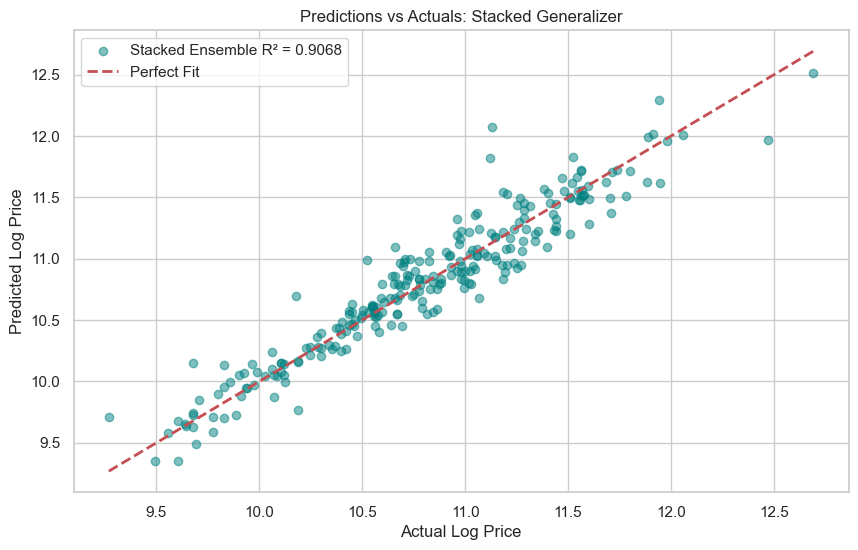

In [5]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', label=f'Stacked Ensemble R² = {r2:.4f}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title(f"Predictions vs Actuals: {best_model_name}")
plt.legend()
plt.show()

## 4. Feature Importance

Top Model: Stacked Generalizer
Calculating Permutation Importance for Stacked Generalizer


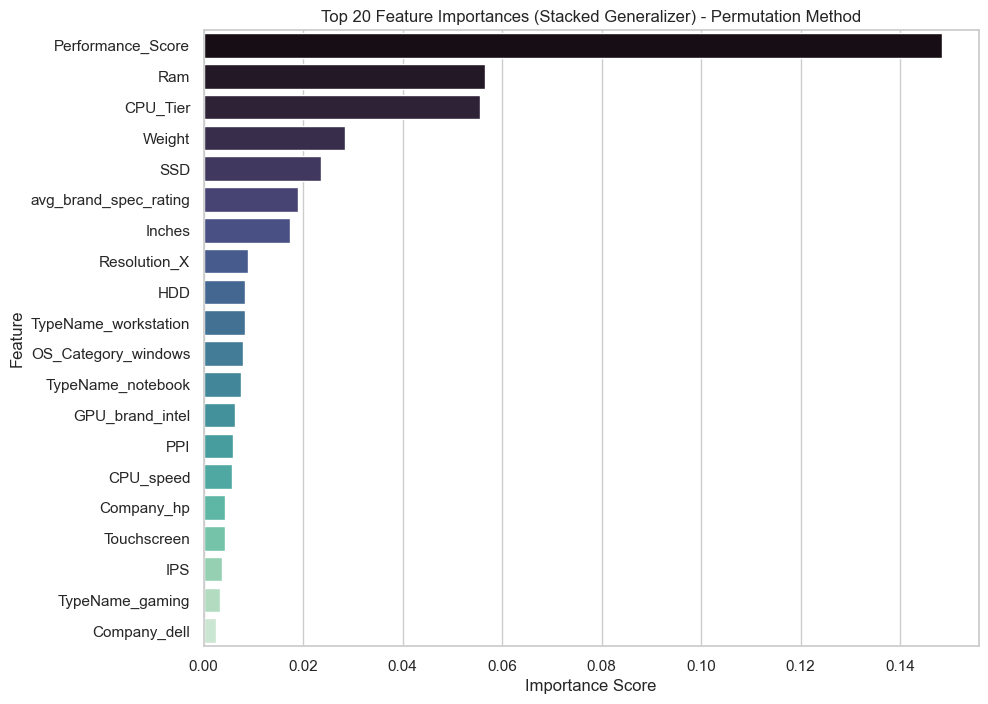

In [6]:
from sklearn.inspection import permutation_importance
import seaborn as sns

# Identify the Absolute Best Model
best_model_name = results_df.iloc[0]["Model"]
best_model_instance = models[best_model_name]

print(f"Top Model: {best_model_name}")

if hasattr(best_model_instance, 'feature_importances_'):
    # Use built-in importance if available (Tree-based)
    print(f"Using built-in feature importances for {best_model_name}...")
    importances = best_model_instance.feature_importances_
    model_method = "Built-in"
else:
    # Use Permutation Importance for Ensemble/Meta-models
    print(f"Calculating Permutation Importance for {best_model_name}")
    # Using a subset of X_test for speed if necessary, but here use the full test set
    r = permutation_importance(best_model_instance, X_test, y_test,
                              n_repeats=10,
                              random_state=42,
                              n_jobs=-1)
    importances = r.importances_mean
    model_method = "Permutation"

# Plotting
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='mako', hue=feat_imp.index, legend=False)
plt.title(f'Top 20 Feature Importances ({best_model_name}) - {model_method} Method')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

This graph shows permutation importance of the best performing model (StackingRegressor). This is used to get the feature_importance, and it works by shuffling a single feature and measuing how much the R^2 score drops, showing exactly how much the ensemble relies on that specific data point. It can be seen that the engineered performance_score feature as well as cpu_tier features influence the model significantly.

## 5. Hyperparameter Tuning for Top 4 Models
Tuning top-performing models using RandomizedSearchCV to find the best configuration for each. RandomizedSearchCV used over GridSearchCV as the gain from an exhaustive Grid Search is usually negligible compared to the time saved by a random search. 

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR

# Hyperparameter Grids
rf_grid = {
    'n_estimators': [100, 300, 500], 
    'max_depth': [10, 20, None], 
    'max_features': ['sqrt', 'log2', None]
}
gb_grid = {
    'n_estimators': [100, 300, 500], 
    'learning_rate': [0.01, 0.05, 0.1], 
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.8, 0.9, 1.0]
}
xgb_grid = {
    'n_estimators': [100, 300, 500, 1000], 
    'learning_rate': [0.01, 0.05, 0.1], 
    'max_depth': [4, 6, 8, 10], 
    'subsample': [0.7, 0.8, 1.0]
}
cat_grid = {
    'iterations': [100, 500, 1000], 
    'learning_rate': [0.01, 0.05, 0.1], 
    'depth': [4, 6, 8, 10], 
    'l2_leaf_reg': [1, 3, 5, 7]
}
et_grid = {
    'n_estimators': [100, 300, 500], 
    'max_depth': [10, 20, None], 
    'min_samples_split': [2, 5, 10]
}
svr_grid = {
    'C': [0.1, 1, 10, 100, 500], 
    'epsilon': [0.01, 0.1, 0.2], 
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

In [8]:
def tune_model(estimator, param_dist, name):
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        estimator=estimator, 
        param_distributions=param_dist, 
        n_iter=20, 
        cv=5, 
        scoring='r2', 
        n_jobs=-1, 
        random_state=42
    )
    search.fit(X_train, y_train)
    
    print(f"--- {name} Results ---")
    metrics = calculate_price_metrics(y_test, search.best_estimator_.predict(X_test))
    print(f"Best CV R2: {search.best_score_:.4f}")
    print(f"Test MAE: {metrics['MAE (Price)']:.2f}, RMSE: {metrics['RMSE (Price)']:.2f}, MAPE: {metrics['MAPE']:.2%}")
    print(f"Optimal Parameters: {search.best_params_}\n")
    
    return search.best_estimator_

best_rf = tune_model(RandomForestRegressor(random_state=42), rf_grid, "Random Forest")
best_gb = tune_model(GradientBoostingRegressor(random_state=42), gb_grid, "Gradient Boosting")
best_xgb = tune_model(XGBRegressor(random_state=42), xgb_grid, "XGBoost")
best_cat = tune_model(CatBoostRegressor(verbose=0, random_state=42), cat_grid, "CatBoost")
best_et = tune_model(ExtraTreesRegressor(random_state=42), et_grid, "Extra Trees")
best_svr = tune_model(SVR(kernel='rbf'), svr_grid, "SVR")

Tuning Random Forest...
--- Random Forest Results ---
Best CV R2: 0.8948
Test MAE: 9349.18, RMSE: 16800.55, MAPE: 14.60%
Optimal Parameters: {'n_estimators': 500, 'max_features': 'log2', 'max_depth': None}

Tuning Gradient Boosting...
--- Gradient Boosting Results ---
Best CV R2: 0.9033
Test MAE: 8816.12, RMSE: 16487.00, MAPE: 14.28%
Optimal Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05}

Tuning XGBoost...
--- XGBoost Results ---
Best CV R2: 0.9064
Test MAE: 9020.21, RMSE: 16197.42, MAPE: 14.64%
Optimal Parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}

Tuning CatBoost...
--- CatBoost Results ---
Best CV R2: 0.9101
Test MAE: 8381.53, RMSE: 15223.89, MAPE: 13.65%
Optimal Parameters: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 6}

Tuning Extra Trees...
--- Extra Trees Results ---
Best CV R2: 0.8791
Test MAE: 9915.24, RMSE: 17539.43, MAPE: 15.99%
Optimal Parameters: {'n_estimato

RandomizedSearchCV with 20 iterations per model was used for hyperparameter tuning. This approach is more efficient than a traditional grid search because it randomly samples the hyperparameter space to find the most impactful combinations without wasting compute on irrelevant permutations. For the boosters (CatBoost, XGBoost, and GB), the tuning specifically focused on the delicate balance between learning_rate and n_estimators (or iterations), searching for a "slow and steady" learning process that allows more trees to capture finer details without causing the model to overfit. Simultaneously, the search explored various max_depth and subsample settings to regulate tree complexity, ensuring the model doesn't just "memorize" specific training samples. For Random Forest, the strategy focused on optimizing max_features and min_samples_split to encourage greater diversity among its 100+ trees, refining its ability to generalize across the entire laptop price spectrum from budget Chromebooks to high-end workstations.

In [9]:
# Final Tuned Stacked Generalizer
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

final_tuned_stack = StackingRegressor(
    estimators=[
        ('xgb', best_xgb),
        ('cat', best_cat),
        ('et', best_et),
        ('svr', best_svr)
    ],
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=-1
)

final_tuned_stack.fit(X_train, y_train)

StackingRegressor(cv=5,
                  estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_co...
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                              ('cat',
                               CatBoostRegressor(depth=6, iterations=1000, l2_leaf_reg=3, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=0)),
                              ('et',
                               ExtraTreesRegressor(max_depth=20,
                                                   min_samples_split=5,
                                                   n_estimators=300,
                                                   random_state=42)),
                              ('svr', SVR(C=10, gamma=0.01))],
                  final_estimator=RidgeCV(), n_jobs=-1)

In [10]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.metrics import r2_score, mean_absolute_error

## Final Performance Report
def evaluate_final(model, name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    # Adjusted R2 Calculation
    n = X_test.shape[0]
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    metrics = calculate_price_metrics(y_test, y_pred)
    res = {"Model": name, "R2 Score": r2, "Adj R2": adj_r2}
    res.update(metrics)
    return res

final_results = [
    evaluate_final(best_rf, "Tuned Random Forest"),
    evaluate_final(best_gb, "Tuned Gradient Boosting"),
    evaluate_final(best_xgb, "Tuned XGBoost"),
    evaluate_final(best_cat, "Tuned CatBoost"),
    evaluate_final(best_et, "Tuned Extra Trees"),
    evaluate_final(best_svr, "Tuned SVR"),
    evaluate_final(final_tuned_stack, "Tuned Stacked Generalizer (Ensemble)")
]

final_df = pd.DataFrame(final_results).sort_values(by="R2 Score", ascending=False)
final_df.to_csv("../results/final_tuned_performance.csv", index=False)
display(final_df[["Model", "R2 Score", "MAE (Price)", "MSE (Price)", "RMSE (Price)", "MAPE"]])

# Identify and save the winner
best_overall_name = final_df.iloc[0]["Model"]
print(f" WINNER: {best_overall_name}")

best_overall_model = None
if best_overall_name == "Tuned Stacked Generalizer (Ensemble)":
    best_overall_model = final_tuned_stack
elif "Random Forest" in best_overall_name: best_overall_model = best_rf
elif "Gradient Boosting" in best_overall_name: best_overall_model = best_gb
elif "XGBoost" in best_overall_name: best_overall_model = best_xgb
elif "CatBoost" in best_overall_name: best_overall_model = best_cat
elif "Extra Trees" in best_overall_name: best_overall_model = best_et
elif "SVR" in best_overall_name: best_overall_model = best_svr

if best_overall_model:
    os.makedirs("../models", exist_ok=True)
    joblib.dump(best_overall_model, "../models/best_laptop_price_model_final.joblib")


,Model,R2 Score,MAE (Price),MSE (Price),RMSE (Price),MAPE
6,Tuned Stacked Generalizer (Ensemble),0.909608,8450.476612,2.317070e+08,15221.925628,0.137906
3,Tuned CatBoost,0.908868,8381.525021,2.317667e+08,15223.885380,0.136523
1,Tuned Gradient Boosting,0.901356,8816.118404,2.718210e+08,16486.996014,0.142822
2,Tuned XGBoost,0.899618,9020.210191,2.623566e+08,16197.424843,0.146367
0,Tuned Random Forest,0.896861,9349.178213,2.822584e+08,16800.548518,0.145959
5,Tuned SVR,0.890310,9377.277940,2.253824e+08,15012.741930,0.158900
4,Tuned Extra Trees,0.880254,9915.242210,3.076314e+08,17539.425172,0.159865


 WINNER: Tuned Stacked Generalizer (Ensemble)


Tuned models follow same patterns as baseline models in terms of R^2, except for Gradient Boosting marginally outperforming XGBoost. This might be because because its greater flexibility in a wide tuning grid allows it to find a more precise local optimum on small datasets, whereas XGBoost's aggressive pruning and regularization might trim beneficial niche branches. However, MAE for Stacked Generalizer becomes higher than that of CatBoost which may be because RidgeCV is optimized to maximize R² by penalizing large errors, occasionally sacrificing the absolute proximity achieved by CatBoost's specialized categorical handling in favor of overall variance explanation and outlier robustness.

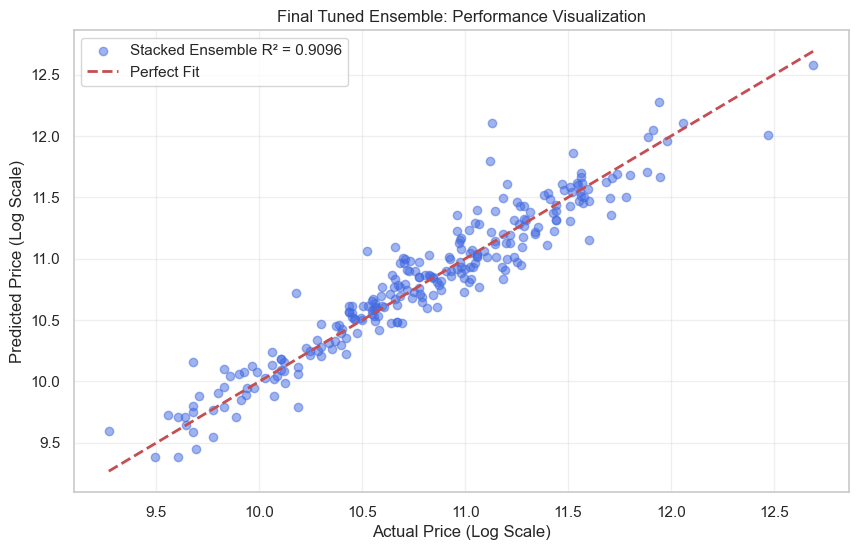

In [11]:
# Visualizing Best Model Fit
y_pred_final = final_tuned_stack.predict(X_test)
r2_final = r2_score(y_test, y_pred_final)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.5, color='royalblue', label=f'Stacked Ensemble R² = {r2_final:.4f}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual Price (Log Scale)")
plt.ylabel("Predicted Price (Log Scale)")
plt.title("Final Tuned Ensemble: Performance Visualization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()